In [3]:
from google.colab import files
uploaded = files.upload()

Saving agriculture_yield_dataset.csv to agriculture_yield_dataset.csv


In [6]:
import io
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

**Part A: Understanding the Dataset**

In [9]:
"""
Q1. Dataset Overview
Load the dataset and answer the following:
- How many rows and columns are present?
- What are the names of all columns?
- Display the first 10 records.
"""

df = pd.read_csv(io.BytesIO(uploaded['agriculture_yield_dataset.csv']))

print("No of rows:", df.shape[0])
print("No of columns:", df.shape[1])
print("Column names: ", df.columns.tolist())
df.head(10)

No of rows: 1500
No of columns: 8
Column names:  ['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


In [10]:
"""
Q2. Data Types and Missing Values
- Check the data type of each column.
- Identify whether any missing values are present.
- If missing values exist, mention the affected columns.
"""

print("Data types of each column:\n")
print(df.dtypes)

print("\nMissing values in each column:\n")
print(df.isnull().sum())

Data types of each column:

rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

Missing values in each column:

rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64


In [13]:
"""
Q3. Descriptive Statistics
Generate summary statistics for all numerical features and answer:
- Which feature has the highest mean value?
- Which feature has the highest standard deviation?
"""

numeric_df = df.select_dtypes(include=[np.number])

print("Summary statistics for numerical features:\n")
print(numeric_df.describe())

print("\nFeature with highest mean value:", numeric_df.mean().idxmax())
print("Feature with highest standard deviation:", numeric_df.std().idxmax())

Summary statistics for numerical features:

       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.40000

**Part B: Exploratory Data Analysis (EDA)**

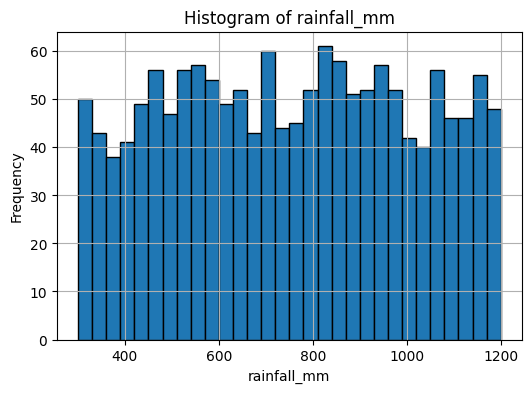

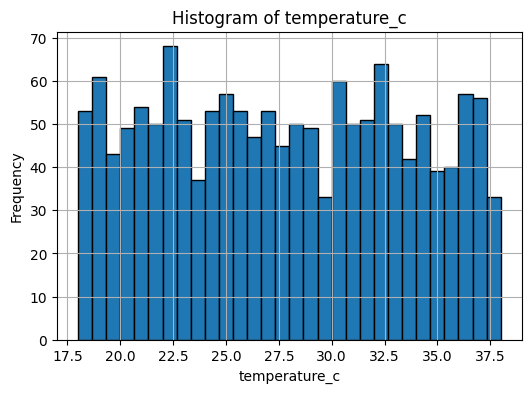

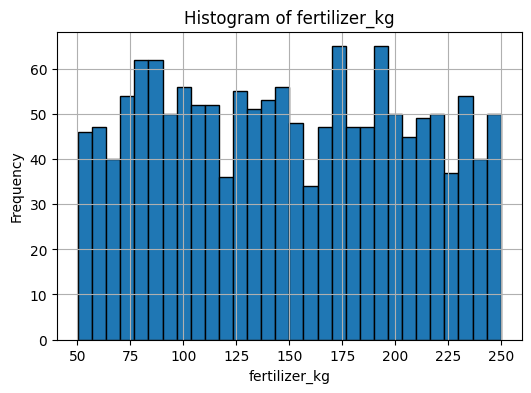

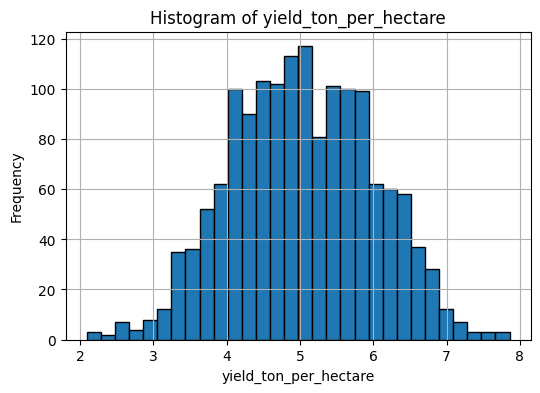

In [14]:
"""
Q4. Distribution Analysis
Create histograms for:
- rainfall_mm
- temperature_c
- fertilizer_kg
- yield_ton_per_hectare
Write 2–3 observations from each histogram.
"""

features = ["rainfall_mm", "temperature_c", "fertilizer_kg", "yield_ton_per_hectare"]

for col in features:
    plt.figure(figsize=(6,4))
    df[col].hist(bins=30, edgecolor="black")
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

Number of records for each crop type:

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


/tmp/ipykernel_994/2199811422.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="crop_type", data=df, order=df["crop_type"].value_counts().index, palette="Set2")


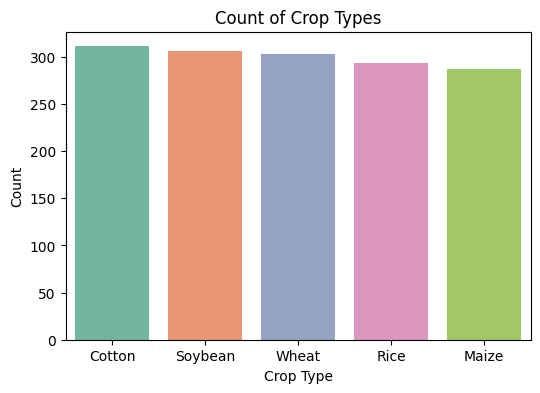

The crop that appears most frequently is: Cotton


In [16]:
print("Number of records for each crop type:\n")
print(df["crop_type"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="crop_type", data=df, order=df["crop_type"].value_counts().index, palette="Set2")
plt.title("Count of Crop Types")
plt.xlabel("Crop Type")
plt.ylabel("Count")
plt.show()

most_frequent_crop = df["crop_type"].value_counts().idxmax()
print("The crop that appears most frequently is:", most_frequent_crop)

Frequency of each soil type:

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


/tmp/ipykernel_994/2230022821.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="soil_type", data=df, order=df["soil_type"].value_counts().index, palette="Set2")


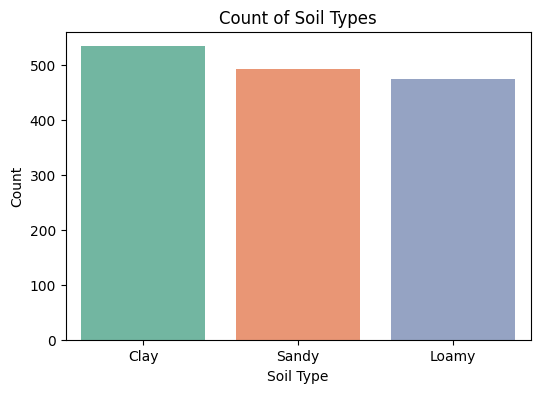

The most common soil type is: Clay


In [17]:
"""
Q6. Soil Type Analysis
- Find the frequency of each soil type.
- Create a count plot for soil_type.
- Which soil type is most common?
"""

print("Frequency of each soil type:\n")
print(df["soil_type"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="soil_type", data=df, order=df["soil_type"].value_counts().index, palette="Set2")
plt.title("Count of Soil Types")
plt.xlabel("Soil Type")
plt.ylabel("Count")
plt.show()

most_common_soil = df["soil_type"].value_counts().idxmax()
print("The most common soil type is:", most_common_soil)

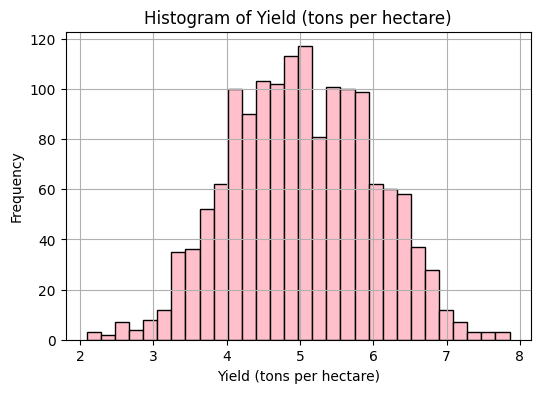

Mean yield: 5.028793333333333
Median yield: 5.01
Number of outliers: 43
Outlier values:
 [2.64 2.97 7.78 2.21 7.28 7.01 2.26 7.07 7.49 2.76 2.89 2.88 7.37 7.14
 7.36 7.04 7.63 7.82 2.82 2.53 7.2  2.86 7.19 7.25 2.82 2.95 2.55 7.29
 7.5  2.34 2.54 2.57 2.87 7.86 7.04 7.12 2.09 2.7  7.07 2.6  7.14 2.64
 2.29]


In [19]:
"""
Q7. Yield Distribution
Create a histogram of yield_ton_per_hectare.
Answer:
 - Is the distribution approximately normal?
 -  Are there any noticeable outliers?
"""

plt.figure(figsize=(6,4))
df["yield_ton_per_hectare"].hist(bins=30, edgecolor="black", color="pink")
plt.title("Histogram of Yield (tons per hectare)")
plt.xlabel("Yield (tons per hectare)")
plt.ylabel("Frequency")
plt.show()

print("Mean yield:", df["yield_ton_per_hectare"].mean())
print("Median yield:", df["yield_ton_per_hectare"].median())

outliers = df[(df["yield_ton_per_hectare"] > 7) | (df["yield_ton_per_hectare"] < 3)]
print("Number of outliers:", len(outliers))
print("Outlier values:\n", outliers["yield_ton_per_hectare"].values)

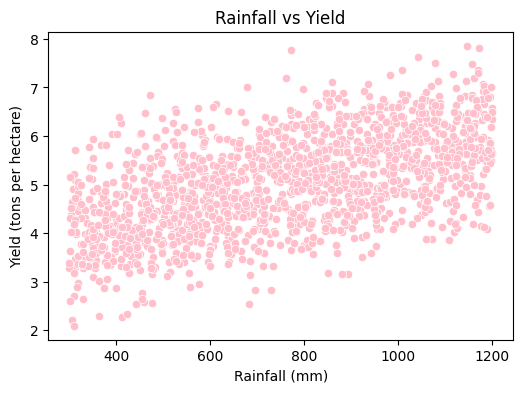

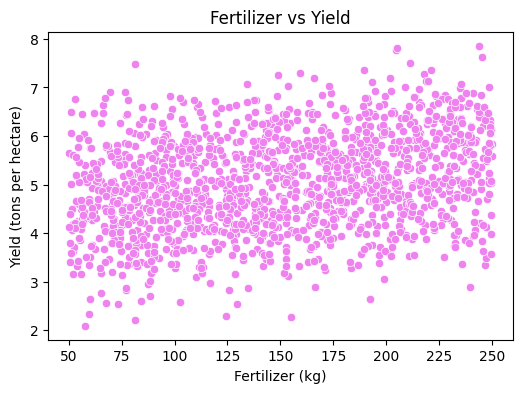

Correlation with yield:
 rainfall_mm              0.553704
fertilizer_kg            0.278043
yield_ton_per_hectare    1.000000
Name: yield_ton_per_hectare, dtype: float64

Feature with strongest correlation to yield: rainfall_mm
Maximum correlation value: 0.5537042408932238


In [23]:
"""
Q8. Scatter Plot Analysis
Create scatter plots of:
1. rainfall_mm vs yield_ton_per_hectare
2. fertilizer_kg vs yield_ton_per_hectare
Based on the plots:
 - Which feature appears to have a stronger relationship with yield?
"""

plt.figure(figsize=(6,4))
sns.scatterplot(x="rainfall_mm", y="yield_ton_per_hectare", data=df, color="pink")
plt.title("Rainfall vs Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tons per hectare)")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x="fertilizer_kg", y="yield_ton_per_hectare", data=df, color="violet")
plt.title("Fertilizer vs Yield")
plt.xlabel("Fertilizer (kg)")
plt.ylabel("Yield (tons per hectare)")
plt.show()
corr_values = df[["rainfall_mm", "fertilizer_kg", "yield_ton_per_hectare"]].corr()["yield_ton_per_hectare"]

print("Correlation with yield:\n", corr_values)
strongest_feature = corr_values.drop("yield_ton_per_hectare").idxmax()
max_corr_value = corr_values.drop("yield_ton_per_hectare").max()
print("\nFeature with strongest correlation to yield:", strongest_feature)
print("Maximum correlation value:", max_corr_value)

Correlation matrix:

                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412   

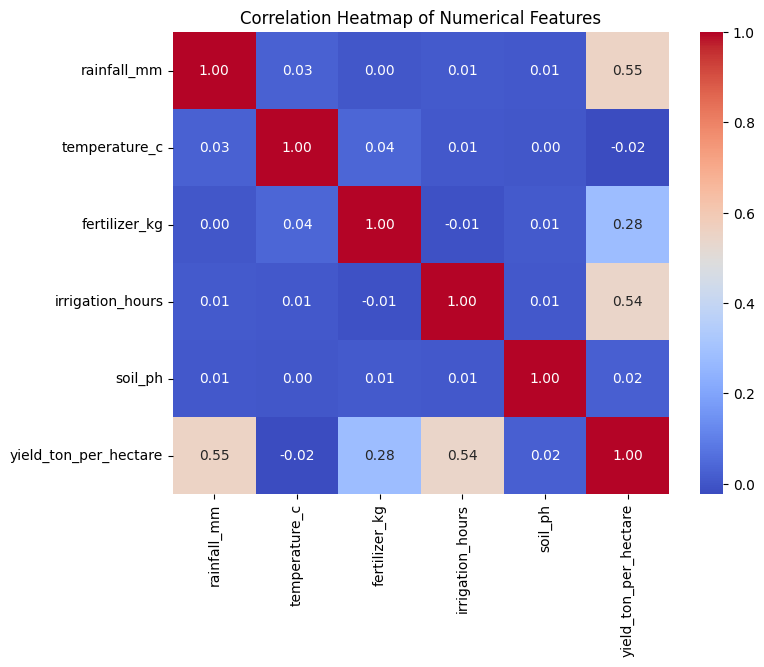


Top 3 features most correlated with crop yield:
 rainfall_mm         0.553704
irrigation_hours    0.542664
fertilizer_kg       0.278043
Name: yield_ton_per_hectare, dtype: float64


In [24]:
"""
Q9. Correlation Analysis
- Generate a correlation matrix for numerical features.
- Create a heatmap.
- Identify the top three features most correlated with crop yield.
"""

corr_matrix = df.select_dtypes(include=[np.number]).corr()

print("Correlation matrix:\n")
print(corr_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

top_features = corr_matrix["yield_ton_per_hectare"].drop("yield_ton_per_hectare").sort_values(ascending=False).head(3)
print("\nTop 3 features most correlated with crop yield:\n", top_features)


In [26]:
"""
Q10. Group-Based Analysis
Calculate the average yield for:
- Each crop type
- Each soil type
Which crop and soil type have the highest average yield?
"""

print("Average yield per crop type:\n")
print(df.groupby("crop_type")["yield_ton_per_hectare"].mean())

print("\nAverage yield per soil type:\n")
print(df.groupby("soil_type")["yield_ton_per_hectare"].mean())

highest_crop = df.groupby("crop_type")["yield_ton_per_hectare"].mean().idxmax()
highest_crop_value = df.groupby("crop_type")["yield_ton_per_hectare"].mean().max()

highest_soil = df.groupby("soil_type")["yield_ton_per_hectare"].mean().idxmax()
highest_soil_value = df.groupby("soil_type")["yield_ton_per_hectare"].mean().max()

print("\nCrop with highest average yield:", highest_crop, "=", highest_crop_value)
print("Soil type with highest average yield:", highest_soil, "=", highest_soil_value)


Average yield per crop type:

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64

Average yield per soil type:

soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64

Crop with highest average yield: Rice = 5.494744027303755
Soil type with highest average yield: Loamy = 5.366518987341772


**Part C: Data Preparation**

In [27]:
"""
Q11. Feature Encoding
The dataset contains categorical variables.
- Identify the categorical columns.
- Convert them into numerical form using One-Hot Encoding.
- Display the first five rows of the transformed dataset.
"""

categorical_cols = df.select_dtypes(include=["object"]).columns
print("Categorical columns:\n", categorical_cols)

df_encoded = pd.get_dummies(df, columns=categorical_cols)

print("\nTransformed dataset (first 5 rows):\n")
print(df_encoded.head())

Categorical columns:
 Index(['crop_type', 'soil_type'], dtype='object')

Transformed dataset (first 5 rows):

   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   yield_ton_per_hectare  crop_type_Cotton  crop_type_Maize  crop_type_Rice  \
0                   5.92             False             True           False   
1                   6.24             False             True           False   
2                   4.77             False            False           False   
3                   4.04             False             True           False   
4                   5.17              True  

In [28]:
"""
Q12. Feature Selection
Separate:
- Input features (X)
- Target variable (y)
Specify which column is being used as the target variable.
"""

y = df_encoded["yield_ton_per_hectare"]

X = df_encoded.drop("yield_ton_per_hectare", axis=1)

print("Shape of input features (X):", X.shape)
print("Shape of target variable (y):", y.shape)

print("\nInput features (X) - first 5 rows:\n", X.head())
print("\nTarget variable (y) - first 5 rows:\n", y.head())

Shape of input features (X): (1500, 13)
Shape of target variable (y): (1500,)

Input features (X) - first 5 rows:
    rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   crop_type_Cotton  crop_type_Maize  crop_type_Rice  crop_type_Soybean  \
0             False             True           False              False   
1             False             True           False              False   
2             False            False           False              False   
3             False             True           False              False   
4              True            False           False       

**Part D: Machine Learning**

In [29]:
"""
Q13. Train-Test Split
Split the dataset into:
- 80% Training Data
- 20% Testing Data
Display the shape of:
- X_train
- X_test
- y_train
- y_test
"""

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (1200, 13)
Shape of X_test: (300, 13)
Shape of y_train: (1200,)
Shape of y_test: (300,)


In [30]:
"""
Q14. Linear Regression Model
 Train a Linear Regression model.
 Display the model coefficients and intercept.
 Which feature has the highest positive coefficient?
"""

lr = LinearRegression()
lr.fit(X_train, y_train)

print("Intercept:", lr.intercept_)
print("\nCoefficients for each feature:\n")

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr.coef_
}).sort_values(by="Coefficient", ascending=False)

print(coef_df)

highest_feature = coef_df.iloc[0]["Feature"]
highest_value = coef_df.iloc[0]["Coefficient"]

print("\nFeature with highest positive coefficient:", highest_feature, "=", highest_value)

Intercept: 1.9111026182800726

Coefficients for each feature:

              Feature  Coefficient
7      crop_type_Rice     0.477369
11    soil_type_Loamy     0.365627
3    irrigation_hours     0.198327
8   crop_type_Soybean     0.095096
10     soil_type_Clay     0.062653
2       fertilizer_kg     0.004978
4             soil_ph     0.004901
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
9     crop_type_Wheat    -0.038149
6     crop_type_Maize    -0.147693
5    crop_type_Cotton    -0.386623
12    soil_type_Sandy    -0.428280

Feature with highest positive coefficient: crop_type_Rice = 0.47736941247826153
